In [1]:
%load_ext autoreload
%autoreload 2

In [18]:
from src.data.datasets.qm9 import QM9Resources, QM9Raw
from src.data.transforms import ToOneHotGraphAdapter

ds = QM9Raw(
    sanitize=False,
    kekulize=True,
    remove_hydrogens=True
)

Extracting datasets/qm9/raw/qm9.zip
Processing molecules: 100%|██████████| 133885/133885 [00:09<00:00, 13663.24it/s, Skipped: 3054 (skip list), 0 (sanit. failed)]


ONC1C2CCC1C2
[[-1.1880e-01  1.3568e+00 -2.2900e-02]
 [ 3.8200e-02 -5.1900e-02 -9.0000e-04]
 [-1.0801e+00 -6.3190e-01  7.1000e-02]
 [-2.5675e+00 -3.0780e-01  2.2100e-02]
 [-2.6343e+00 -1.5628e+00 -9.1550e-01]
 [-1.4839e+00 -2.0930e+00  8.4000e-03]
 [-2.2262e+00 -2.2527e+00  1.3577e+00]
 [-3.0405e+00 -9.0910e-01  1.3681e+00]]


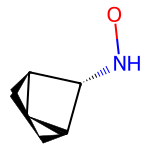

In [41]:
from copy import deepcopy
from rdkit.Chem import Draw
from src.data.simple_transforms.molecular import mol2smiles

idx = 4127
mol = deepcopy(ds[idx][0])
print(mol2smiles(mol))
true_pos = mol.GetConformer().GetPositions()
print(true_pos)
Draw.MolToImage(mol, size=(150, 150))

In [42]:
# delete conformer if present
mol.RemoveAllConformers()
print(mol.GetNumConformers())

0


In [43]:
from src.data.simple_transforms.molecular import verify_and_compute_3d_conformer

mol = verify_and_compute_3d_conformer(mol)
gen_pos = mol.GetConformer().GetPositions()
print(gen_pos)

[[-2.17989175  1.03626182  1.68915254]
 [-0.91322782  0.64300201  1.55680312]
 [-0.40140543  0.81745972  0.22263024]
 [ 1.0390376   0.36757377  0.08241498]
 [ 0.46774383 -1.05714698  0.06071063]
 [-0.66481361 -0.36779488 -0.71350172]
 [ 0.03930692  0.01620594 -1.96904667]
 [ 1.2888311   0.6842809  -1.36104732]]


In [45]:
from rdkit import Chem
import torch
mol_block = Chem.MolToMolBlock(mol)
            
coordinates = []
lines = mol_block.splitlines()
for line in lines[4:4 + mol.GetNumAtoms()]:  # The coordinates start at line 5
    parts = line.split()
    # Extract the x, y, z coordinates (3rd, 4th, and 5th columns)
    x, y, z = map(float, parts[0:3])
    for elem in [x,y,z]:
        coordinates.append(elem)

n=len(coordinates)

pos = torch.tensor(coordinates, dtype=torch.float32).view(int(n/3),3)
print(pos)

tensor([[-2.1799,  1.0363,  1.6892],
        [-0.9132,  0.6430,  1.5568],
        [-0.4014,  0.8175,  0.2226],
        [ 1.0390,  0.3676,  0.0824],
        [ 0.4677, -1.0571,  0.0607],
        [-0.6648, -0.3678, -0.7135],
        [ 0.0393,  0.0162, -1.9690],
        [ 1.2888,  0.6843, -1.3610]])


In [55]:
# compare true_pos and gen_pos, are they a rotation and translation of each other?

import numpy as np
from scipy.spatial.transform import Rotation as R
from scipy.spatial import procrustes
mtx1, mtx2, disparity = procrustes(true_pos, gen_pos)
print("Disparity after Procrustes analysis:", disparity)

Disparity after Procrustes analysis: 0.12368883477455322


In [6]:
from src.data.datasets.zinc import ZincMolecules

ds = ZincMolecules(
    remove_hydrogens=True, compute_3d_conformer=True,
    num_workers=8
)

Using existing file zinc250k.csv
Using existing file valid_idx_zinc250k.json


Molecules and properties files already exist, loading them...
Loaded 249419 molecules from files. If this should not be the case, please delete the files and re-run.


Computing molecules stats: 100%|██████████| 249419/249419 [03:30<00:00, 1183.42it/s]


NC(=NOCc1ccc(Br)cc1F)C1CCOC1


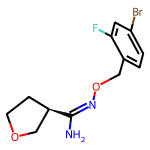

In [11]:
from copy import deepcopy
from rdkit.Chem import Draw
from src.data.simple_transforms.molecular import mol2smiles

idx = 4127
mol = deepcopy(ds[idx][0])
print(mol2smiles(mol))
Draw.MolToImage(mol, size=(150, 150))

In [21]:
from src.data.simple_transforms.molecular import verify_and_compute_3d_conformer

mol = verify_and_compute_3d_conformer(mol)
gen_pos = mol.GetConformer().GetPositions()
print(gen_pos)

[[-0.69125718 -2.07671237  1.05215359]
 [-0.56848633 -1.090783    0.02277626]
 [ 0.57319093 -0.49034742 -0.12976186]
 [ 0.77607656  0.49476674 -1.07209039]
 [ 2.02895403  1.15568519 -1.17037165]
 [ 2.26734281  1.99181151  0.05724233]
 [ 3.12158656  1.52973473  1.07230127]
 [ 3.31627011  2.28881931  2.23002958]
 [ 2.65282202  3.509305    2.38833523]
 [ 2.918046    4.54297924  3.97219515]
 [ 1.78989851  3.96922255  1.38868165]
 [ 1.59163702  3.21342087  0.2283899 ]
 [ 0.73878473  3.66909266 -0.72410774]
 [-1.77846301 -0.72046584 -0.8213231 ]
 [-2.85775971 -0.05786636  0.00995414]
 [-4.05347061 -0.98521477 -0.12418828]
 [-3.61539888 -2.22243047 -0.62848568]
 [-2.47329283 -1.94906294 -1.40038061]]


In [13]:
from src.data.datasets.zinc import Zinc

ds = Zinc(
    sanitize=False,
    remove_hydrogens=True,
    kekulize=True,
    hard_remove_hydrogens=False,
    include_pos=True,
    include_charges=True,
)

Computing molecules stats: 100%|██████████| 100/100 [00:00<00:00, 1309.77it/s]
Processing...
Converting Chem.Mols to SparseGraphs: 100%|██████████| 100/100 [00:00<00:00, 808.69it/s]
Done!


In [1]:
from src.data.datasets.gdb13 import GDB13

ds = GDB13(
    sanitize=False,
    remove_hydrogens=True,
    kekulize=True,
    hard_remove_hydrogens=False,
    include_pos=True,
    include_charges=True,
)

/opt/homebrew/Caskroom/miniconda/base/envs/ifh-gen/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using existing file gdb13.rand1M.smi.gz
Extracting datasets/gdb13/raw/gdb13.rand1M.smi.gz
Reading SMILES: 100%|██████████| 999999/999999 [00:26<00:00, 37620.83it/s]
Converting raw Chem.Mols to processed Chem.Mols:   0%|          | 46/999999 [00:02<15:12:27, 18.26it/s]

Could not compute a conformer for [H]N([H])C12C([H])([H])N3C([H])([H])C4([H])C([H])(C3([H])C1([H])[H])C(N([H])[H])(C([H])([H])[H])C42[H]: Bad Conformer Id
None


Converting raw Chem.Mols to processed Chem.Mols:   0%|          | 74/999999 [00:03<13:56:36, 19.92it/s]

Could not compute a conformer for [H]OC1([H])C2([H])N3C4([H])C([H])([H])N5C([H])([H])C2([H])C([H])(C54[H])C31C([H])([H])[H]: Bad Conformer Id
None


Converting raw Chem.Mols to processed Chem.Mols:   0%|          | 100/999999 [00:03<10:47:03, 25.76it/s]
Computing molecules stats: 100%|██████████| 98/98 [00:00<00:00, 1278.04it/s]
Processing...
Converting Chem.Mols to SparseGraphs: 100%|██████████| 98/98 [00:00<00:00, 690.46it/s]
Done!
/opt/homebrew/Caskroom/miniconda/base/envs/ifh-gen/lib/python3.11/site-packages/torch_geometric/io/fs.py:229: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([SparseGraph])` to allowlist this global.
  warnings.warn(f"{warn_msg} Please use "


In [11]:
ds[58]

SparseGraph(x=[12], edge_index=[2, 28], edge_attr=[28], node_pos=[12, 3], node_charges=[12], y=[0])

In [ ]:
# load pickle
import pickle

with open('datasets/geom-drugs/raw/train_data.pickle', 'rb') as f:
    data = pickle.load(f)

In [48]:
len(data)

30434

In [47]:
from src.data.simple_transforms.molecular import mol2smiles
print(data[0][0])
print(mol2smiles(data[0][1][0]))
print(mol2smiles(data[0][1][8]))
print(mol2smiles(data[0][1][9]))

Brc1c(CSc2nncn2-c2ccccc2)nc2ncccn12
[H]c1nc2nc(C([H])([H])Sc3nnc([H])n3-c3c([H])c([H])c([H])c([H])c3[H])c(Br)n2c([H])c1[H]
[H]c1nc2nc(C([H])([H])Sc3nnc([H])n3-c3c([H])c([H])c([H])c([H])c3[H])c(Br)n2c([H])c1[H]
[H]c1nc2nc(C([H])([H])Sc3nnc([H])n3-c3c([H])c([H])c([H])c([H])c3[H])c(Br)n2c([H])c1[H]


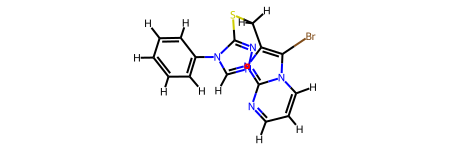

In [ ]:
mol = data[0][1][0]
mol

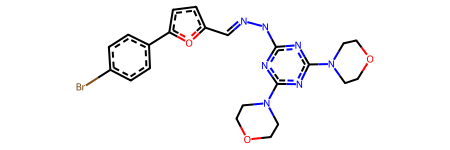

In [65]:
import src.data.utils.molecular as molutils

mol = data[2][1][0]

mol = molutils.kekulize_molecule(mol)

mol = molutils.remove_hydrogens_from_molecule(mol)
mol

In [2]:
from src.data.datasets.geom_drugs import GeomDrugsRaw

ds = GeomDrugsRaw(
    split='train',
    sanitize=False,
    remove_hydrogens=True,
    kekulize=True
)

In [1]:
from src.data.datasets.geom_drugs import GeomDrugs

ds = GeomDrugs(
    split='train',
    sanitize=False,
    remove_hydrogens=True,
    kekulize=True,
    hard_remove_hydrogens=False,
    include_pos=True,
    include_charges=True
)


/opt/homebrew/Caskroom/miniconda/base/envs/ifh-gen/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Processing...
Converting Chem.Mols to SparseGraphs: 100%|██████████| 146411/146411 [03:14<00:00, 751.73it/s]
Done!
/opt/homebrew/Caskroom/miniconda/base/envs/ifh-gen/lib/python3.11/site-packages/torch_geometric/io/fs.py:229: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([SparseGraph])` to allowlist this global.
  warnings.warn(f"{warn_msg} Please use "


In [6]:
ds[6]

SparseGraph(x=[19], edge_index=[2, 44], edge_attr=[44], node_pos=[19, 3], node_charges=[19])

In [1]:
from src.data.datasets.qm9 import QM9Raw

ds = QM9Raw()

In [19]:
mols_with_h = []

for mol, props in ds:
    # if mol has hydrogens break and return it
    if mol.GetNumAtoms() != mol.GetNumHeavyAtoms():
        mols_with_h.append(mol)
        
print(f'{len(mols_with_h)}/{len(ds)} molecules have hydrogens')

1141/130831 molecules have hydrogens


[H]N=C(C)NC=O


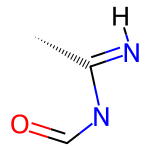

In [20]:
# display mol
from src.data.simple_transforms.molecular import mol2smiles


mol = mols_with_h[1]

print(mol2smiles(mol))
Draw.MolToImage(mol, size=(150, 150))

In [21]:
from rdkit import Chem

# store also smiles
writer = Chem.SDWriter('qm9_with_h.sdf')
for i, mol in enumerate(mols_with_h):
    mol.SetProp('ID', 'Molecule_'+str(i))
    mol.SetProp('SMILES', mol2smiles(mol))
    for cid in range(mol.GetNumConformers()):
        writer.write(mol, confId=cid)
writer.close()

In [ ]:
# save as pickle
import pickle

mols_with_h_and_smiles = [(mol, mol2smiles(mol)) for mol in mols_with_h]

with open('mols_with_h.pkl', 'wb') as f:
    pickle.dump(mols_with_h_and_smiles, f)

[H]N=CNC=O


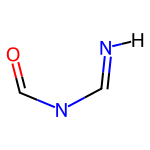

In [13]:
# read pickle
import pickle
from rdkit.Chem import Draw

with open('mols_with_h.pkl', 'rb') as f:
    mols_with_h_and_smiles = pickle.load(f)
    
mol, smiles = mols_with_h_and_smiles[0]
print(smiles)
Draw.MolToImage(mol, size=(150, 150))

In [7]:
from src.data.datasets.zinc import ZincResources
from src.data.transforms import ToOneHotGraphAdapter

data_resources = ZincResources(
    random_splits={
        'train': None,
        'valid': 0.1,
        'test': None
    },
    pre_transform=[
        ToOneHotGraphAdapter({
            'x': 'num_cls_nodes',
            'edge_attr': 'num_cls_edges',
            'node_charges': 'num_cls_charges'
        })
    ],
    sanitize=False,
    kekulize=True,
    remove_hydrogens=True,
    hard_remove_hydrogens=False,
    include_pos=True,
    include_charges=True,
    num_workers=0,
    chunksize=1000
)

data_resources.prepare_data()

/opt/homebrew/Caskroom/miniconda/base/envs/ifh-gen/lib/python3.11/site-packages/torch_geometric/io/fs.py:229: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([SparseGraph])` to allowlist this global.
  warnings.warn(f"{warn_msg} Please use "


In [10]:
from src.data.datasets.gdb13 import GDB13Resources
from src.data.transforms import ToOneHotGraphAdapter

data_resources = GDB13Resources(
    random_splits={
        'train': None,
        'valid': 0.1,
        'test': 0.2
    },
    pre_transform=[
        ToOneHotGraphAdapter({
            'x': 'num_cls_nodes',
            'edge_attr': 'num_cls_edges',
            'node_charges': 'num_cls_charges'
        })
    ],
    sanitize=False,
    kekulize=True,
    remove_hydrogens=True,
    hard_remove_hydrogens=False,
    include_pos=True,
    include_charges=True,
    num_workers=0,
    chunksize=1000
)

data_resources.prepare_data()

In [1]:
from src.data.datasets.geom_drugs import GeomDrugsResources
from src.data.transforms import ToOneHotGraphAdapter

data_resources = GeomDrugsResources(
    pre_transform=[
        ToOneHotGraphAdapter({
            'x': 'num_cls_nodes',
            'edge_attr': 'num_cls_edges',
            'node_charges': 'num_cls_charges'
        })
    ],
    sanitize=False,
    kekulize=True,
    remove_hydrogens=True,
    hard_remove_hydrogens=False,
    include_pos=True,
    include_charges=True,
)

data_resources.prepare_data()

/opt/homebrew/Caskroom/miniconda/base/envs/ifh-gen/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/homebrew/Caskroom/miniconda/base/envs/ifh-gen/lib/python3.11/site-packages/torch_geometric/io/fs.py:229: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([SparseGraph])` to allowlist this global.
  warnings.warn(f"{warn_msg} Please use "
/opt/homebrew/Caskroom/miniconda/base/envs/ifh-gen/lib/python3.11/site-packages/torch_geometric/data/dataset.py:240: UserWarning: The `pre_transform` argument differs from the one used in the pre-processed version of this dataset. If you want to make use of another pre-processing technique, pass `force_reload=True` explicitly to reload the datas

In [2]:
ds_train = data_resources.get('dataset', 'train')
ds_valid = data_resources.get('dataset', 'valid')
ds_test = data_resources.get('dataset', 'test')
print(len(ds_train), len(ds_valid), len(ds_test))

146411 146411 146411


In [15]:
(ds_train.x == ds_valid.x).all()

tensor(True)

In [16]:
ds_train_sm = data_resources.get('smiles', 'train')
ds_valid_sm = data_resources.get('smiles', 'valid')
ds_test_sm = data_resources.get('smiles', 'test')

In [17]:
ds_train_sm[0]

'Brc1c(CSc2nncn2-c2ccccc2)nc2ncccn12'